Dataset Shape: (5000, 9)

Sample Dataset:


,duration,packets,bytes,failed_logins,connections,port,request_rate,packet_size,attack_type
0,2.346340,48,5969.068015,2,9,8080,15.373499,492.090381,Normal
1,15.050607,59,3337.737955,0,16,53,16.006324,454.869281,Normal
2,6.583728,59,6023.733814,2,13,443,17.231552,285.669465,Normal
3,4.564713,56,5434.676718,1,11,23,22.339150,816.094556,Normal
4,0.848124,43,8499.553343,2,7,445,20.452908,485.225601,Normal



Attack Distribution:


attack_type
Normal         4325
Brute Force     241
Web Attack      234
Port Scan       134
DDoS             66
Name: count, dtype: int64

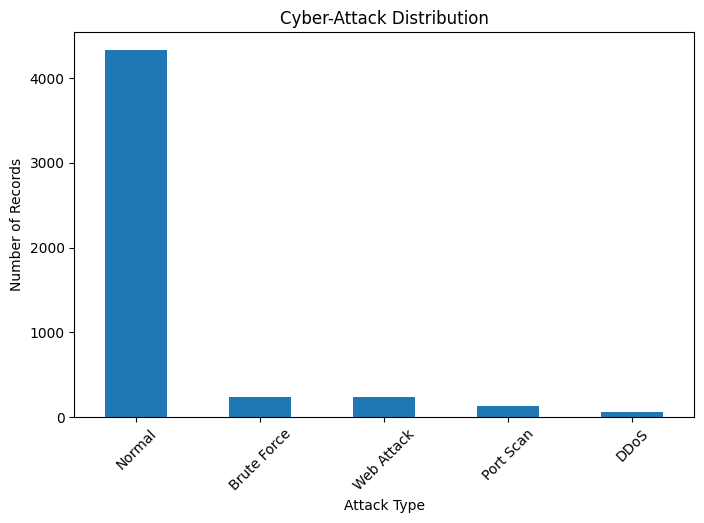


Random Forest Accuracy:
98.90%

Classification Report:
              precision    recall  f1-score   support

 Brute Force       0.96      1.00      0.98        48
        DDoS       1.00      0.85      0.92        13
      Normal       1.00      0.99      0.99       865
   Port Scan       1.00      0.93      0.96        27
  Web Attack       0.90      0.96      0.93        47

    accuracy                           0.99      1000
   macro avg       0.97      0.94      0.96      1000
weighted avg       0.99      0.99      0.99      1000



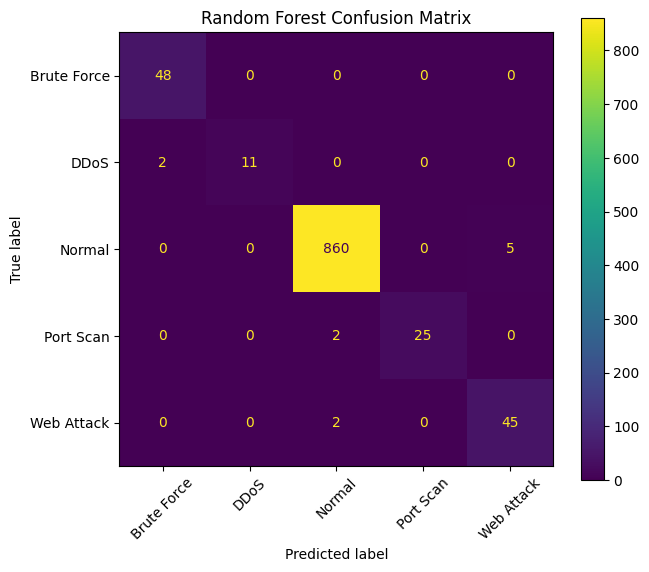


Feature Importance:


,Feature,Importance
6,request_rate,0.314990
3,failed_logins,0.245221
4,connections,0.209257
5,port,0.073599
1,packets,0.056618
0,duration,0.048818
7,packet_size,0.027442
2,bytes,0.024054


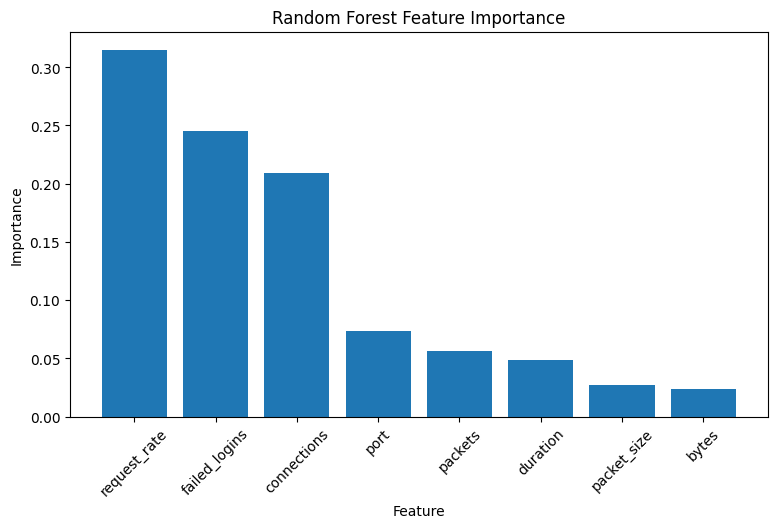


New Traffic Prediction:
Predicted Attack Type: DDoS

Synthetic dataset saved successfully.


In [1]:
# Experiment 3: Implement an ensemble learning method (e.g., Random Forest or Gradient Boosting) to classify cyber-attacks. 
# ============================================================
# CYBER-ATTACK CLASSIFICATION USING RANDOM FOREST
# Synthetic Dataset
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Make results reproducible
np.random.seed(42)


# ============================================================
# 2. CREATE SYNTHETIC CYBERSECURITY DATASET
# ============================================================

n_samples = 5000

data = pd.DataFrame({

    # Duration of network connection
    "duration": np.random.exponential(
        scale=5, size=n_samples
    ),

    # Number of packets
    "packets": np.random.poisson(
        lam=50, size=n_samples
    ),

    # Number of bytes transferred
    "bytes": np.random.normal(
        loc=5000, scale=1500, size=n_samples
    ),

    # Failed login attempts
    "failed_logins": np.random.poisson(
        lam=2, size=n_samples
    ),

    # Number of connections
    "connections": np.random.poisson(
        lam=10, size=n_samples
    ),

    # Common network ports
    "port": np.random.choice(
        [21, 22, 23, 25, 53, 80, 443, 445, 8080],
        size=n_samples
    ),

    # Requests per second
    "request_rate": np.random.normal(
        loc=20, scale=8, size=n_samples
    ),

    # Average packet size
    "packet_size": np.random.normal(
        loc=500, scale=100, size=n_samples
    )
})


# Make sure values are positive
data["duration"] = data["duration"].clip(lower=0.1)
data["bytes"] = data["bytes"].clip(lower=100)
data["request_rate"] = data["request_rate"].clip(lower=1)
data["packet_size"] = data["packet_size"].clip(lower=50)


# ============================================================
# 3. GENERATE CYBER-ATTACK LABELS
# ============================================================

labels = []

for i in range(n_samples):

    # -------------------------
    # DDoS
    # High request rate + many packets
    # -------------------------
    if (
        data.loc[i, "request_rate"] > 35
        and data.loc[i, "packets"] > 50
    ):
        labels.append("DDoS")

    # -------------------------
    # Brute Force
    # Many failed login attempts
    # -------------------------
    elif data.loc[i, "failed_logins"] >= 5:
        labels.append("Brute Force")

    # -------------------------
    # Port Scan
    # Many connections in short duration
    # -------------------------
    elif (
        data.loc[i, "connections"] > 15
        and data.loc[i, "duration"] < 5
    ):
        labels.append("Port Scan")

    # -------------------------
    # Web Attack
    # Web ports + high request rate
    # FIXED: use "in" instead of ".isin()"
    # -------------------------
    elif (
        data.loc[i, "port"] in [80, 443, 8080]
        and data.loc[i, "request_rate"] > 28
    ):
        labels.append("Web Attack")

    # -------------------------
    # Normal Traffic
    # -------------------------
    else:
        labels.append("Normal")


# Add attack type as target column
data["attack_type"] = labels


# ============================================================
# 4. DISPLAY ONLY IMPORTANT DATA
# ============================================================

print("Dataset Shape:", data.shape)

print("\nSample Dataset:")
display(data.head())

print("\nAttack Distribution:")
display(data["attack_type"].value_counts())


# ============================================================
# 5. VISUALIZE ATTACK DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

data["attack_type"].value_counts().plot(kind="bar")

plt.title("Cyber-Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()


# ============================================================
# 6. SEPARATE FEATURES AND TARGET
# ============================================================

X = data.drop("attack_type", axis=1)

y = data["attack_type"]


# ============================================================
# 7. SPLIT DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 8. CREATE RANDOM FOREST MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)


# ============================================================
# 9. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 11. MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Accuracy:")
print(f"{accuracy * 100:.2f}%")


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(ax=ax)

plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=45)

plt.show()


# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")

display(feature_importance)


# ============================================================
# 15. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 16. TEST WITH NEW NETWORK TRAFFIC
# ============================================================

new_connection = pd.DataFrame({
    "duration": [2],
    "packets": [100],
    "bytes": [8000],
    "failed_logins": [1],
    "connections": [12],
    "port": [80],
    "request_rate": [45],
    "packet_size": [500]
})


# Predict attack
prediction = model.predict(new_connection)


print("\nNew Traffic Prediction:")
print("Predicted Attack Type:", prediction[0])


# ============================================================
# 17. SAVE DATASET
# ============================================================

data.to_csv(
    "synthetic_cyber_attack_dataset.csv",
    index=False
)

print("\nSynthetic dataset saved successfully.")